In [1]:
from datasets import load_dataset

ds = load_dataset("uqa/UQA") # splits : train , validation
print (ds)

ex = ds["train"][0]
print(ex.keys()) # id , title , context , question, answers
print(ex["question"])
print(ex["answer"]) # { ’ text ’: [...] , ’ answer_start ’: [...]}
n_total = len(ds["train"])
n_ans = sum(len(a.strip()) > 0 for a in ds["train"]["answer"])
print(f"train rowssssss: {n_total}, answerable: {n_ans}")

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 124745
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 16824
    })
})
dict_keys(['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'])
بیونس نے کب مقبولیت حاصل کرنا شروع کی؟
1990 کی دہائی کے آخر میں
train rowssssss: 124745, answerable: 83018


In [2]:
import csv

ANS_OPEN, ANS_CLOSE = "<ans>", "</ans>"

# Urdu full stop U+06D4, Urdu question mark U+061F, exclamation mark
SENT_DELIMS = "\u06D4\u061F!"

def split_sentences(text):
    """Yield (start, end, sentence) with offsets into text."""
    start = 0

    for i, ch in enumerate(text):
        if ch in SENT_DELIMS:
            yield start, i + 1, text[start:i + 1]
            start = i + 1

    if start < len(text):
        yield start, len(text), text[start:]


def make_pair(example, max_src=60, max_tgt=25):
    """Return (source, target) or None if the row is unusable."""

    answer = example["answer"]
    a_start = example["answer_start"]

    if not answer or len(answer.strip()) == 0:
        return None

    a_text = answer
    a_end = a_start + len(a_text)

    context = example["context"]

    for s, e, sent in split_sentences(context):

        if s <= a_start < e:
            rel = a_start - s  # offset inside the sentence

            if sent[rel:rel + len(a_text)] != a_text:
                return None  # offset mismatch -> skip

            src = (
                sent[:rel]
                + " "
                + ANS_OPEN
                + " "
                + a_text
                + " "
                + ANS_CLOSE
                + " "
                + sent[rel + len(a_text):]
            ).strip()

            src = " ".join(src.split())  # normalize whitespace
            tgt = " ".join(example["question"].split())

            if len(src.split()) > max_src or len(tgt.split()) > max_tgt:
                return None

            return src, tgt

    return None


def build_split(split, out_path):
    pairs = [p for p in map(make_pair, split) if p is not None]

    with open(out_path, "w", encoding="utf-8", newline="") as f:
        w = csv.writer(
            f,
            delimiter="\t",
            quoting=csv.QUOTE_NONE,
            escapechar="\\"
        )

        w.writerows(pairs)

    print(f"{out_path}: {len(pairs)} pairs")
    return pairs


train_pairs = build_split(ds["train"], "train.tsv")
valid_pairs = build_split(ds["validation"], "valid.tsv")

train.tsv: 75067 pairs
valid.tsv: 10018 pairs


In [3]:
import sentencepiece as spm

# One line per sentence: sources and targets from the TRAIN split only
with open("sp_corpus.txt", "w", encoding="utf-8") as f:
    for src, tgt in train_pairs:
        f.write(src + "\n" + tgt + "\n")



In [4]:
spm.SentencePieceTrainer.train(
    input="sp_corpus.txt",
    model_prefix="ur_sp",
    vocab_size=8000,
    model_type="unigram",
    character_coverage=1.0,  # keep every Urdu character
    user_defined_symbols=[ANS_OPEN, ANS_CLOSE],
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,
)

sp = spm.SentencePieceProcessor(model_file="ur_sp.model")
PAD, UNK, BOS, EOS = 0, 1, 2, 3

src, tgt = train_pairs[0]

print(sp.encode(src, out_type=str))  # pieces
print(sp.encode(tgt))                 # ids
print(sp.decode(sp.encode(tgt)) == tgt)  # round-trip check

['▁ہیوسٹن', '▁،', '▁ٹیکساس', '▁میں', '▁پیدا', '▁ہوئی', '▁اور', '▁اس', '▁کی', '▁پرورش', '▁ہوئی', '▁،', '▁اس', '▁نے', '▁بچپن', '▁میں', '▁مختلف', '▁گانے', '▁اور', '▁رقص', '▁کے', '▁مقابلوں', '▁میں', '▁پرفارم', '▁کیا', '▁،', '▁اور', '▁', '<ans>', '▁1990', '▁کی', '▁دہائی', '▁کے', '▁آخر', '▁میں', '▁', '</ans>', '▁R', '&', 'B', '▁گر', 'ل', '▁گروپ', '▁ڈسٹنی', '▁چائلڈ', '▁کے', '▁لیڈ', '▁گلوکار', '▁کی', '▁حیثیت', '▁سے', '▁شہرت', '▁حاصل', '▁کی۔']
[2757, 18, 83, 2810, 100, 151, 99, 9, 11]
True


In [5]:
# Show five tokenized examples
for i, (src, tgt) in enumerate(train_pairs[:5], start=1):
    print(f"\nExample {i}")

    print("Source:")
    print(src)
    print("Tokens:")
    print(sp.encode(src, out_type=str))

    print("\nTarget:")
    print(tgt)
    print("Tokens:")
    print(sp.encode(tgt, out_type=str))

    decoded_src = sp.decode(sp.encode(src))
    decoded_tgt = sp.decode(sp.encode(tgt))


    print("Source round-trip:", decoded_src == src)
    print("Target round-trip:", decoded_tgt == tgt)


Example 1
Source:
ہیوسٹن ، ٹیکساس میں پیدا ہوئی اور اس کی پرورش ہوئی ، اس نے بچپن میں مختلف گانے اور رقص کے مقابلوں میں پرفارم کیا ، اور <ans> 1990 کی دہائی کے آخر میں </ans> R&B گرل گروپ ڈسٹنی چائلڈ کے لیڈ گلوکار کی حیثیت سے شہرت حاصل کی۔
Tokens:
['▁ہیوسٹن', '▁،', '▁ٹیکساس', '▁میں', '▁پیدا', '▁ہوئی', '▁اور', '▁اس', '▁کی', '▁پرورش', '▁ہوئی', '▁،', '▁اس', '▁نے', '▁بچپن', '▁میں', '▁مختلف', '▁گانے', '▁اور', '▁رقص', '▁کے', '▁مقابلوں', '▁میں', '▁پرفارم', '▁کیا', '▁،', '▁اور', '▁', '<ans>', '▁1990', '▁کی', '▁دہائی', '▁کے', '▁آخر', '▁میں', '▁', '</ans>', '▁R', '&', 'B', '▁گر', 'ل', '▁گروپ', '▁ڈسٹنی', '▁چائلڈ', '▁کے', '▁لیڈ', '▁گلوکار', '▁کی', '▁حیثیت', '▁سے', '▁شہرت', '▁حاصل', '▁کی۔']

Target:
بیونس نے کب مقبولیت حاصل کرنا شروع کی؟
Tokens:
['▁بیونس', '▁نے', '▁کب', '▁مقبولیت', '▁حاصل', '▁کرنا', '▁شروع', '▁کی', '؟']
Source round-trip: True
Target round-trip: True

Example 2
Source:
ہیوسٹن ، ٹیکساس میں پیدا اور پرورش پائی ، اس نے بچپن میں مختلف <ans> گانے اور رقص </ans> کے مقابلوں میں پرفارم کی

In [ ]:
!pip install datasets sentencepiece sacrebleu rouge-score torch seaborn matplotlib --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 14.3 MB/s eta 0:00:00


In [ ]:
import sacrebleu
from rouge_score import rouge_scorer


def score(hyps, refs):
    bleu = sacrebleu.corpus_bleu(hyps, [refs]).score

    scorer = rouge_scorer.RougeScorer(
        ["rougeL"],
        use_stemmer=False
    )

    rl = sum(
        scorer.score(r, h)["rougeL"].fmeasure
        for h, r in zip(hyps, refs)
    ) / len(refs)

    unk_rate = sum(
        h.count("\u2047") for h in hyps
    ) / max(
        1,
        sum(len(h.split()) for h in hyps)
    )  # SP decodes <unk> as U+2047

    return {
        "BLEU-4": bleu,
        "ROUGE-L": rl,
        "unk_rate": unk_rate
    }

In [6]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import torch
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence

PAD, UNK, BOS, EOS = 0, 1, 2, 3

class QGDataset(Dataset):
    def __init__(self, tsv_path, sp):
        self.pairs = []
        with open(tsv_path, encoding="utf-8") as f:
            for line in f:
                line = line.rstrip("\n")
                if not line:
                    continue
                src, tgt = line.split("\t")
                self.pairs.append((src, tgt))
        self.sp = sp

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = self.sp.encode(src)
        tgt_ids = [BOS] + self.sp.encode(tgt) + [EOS]
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)


def collate_fn(batch):
    src_seqs, tgt_seqs = zip(*batch)
    src_lens = torch.tensor([len(s) for s in src_seqs])
    tgt_lens = torch.tensor([len(t) for t in tgt_seqs])

    src_padded = pad_sequence(src_seqs, batch_first=True, padding_value=PAD)
    tgt_padded = pad_sequence(tgt_seqs, batch_first=True, padding_value=PAD)

    return src_padded, src_lens, tgt_padded, tgt_lens


if __name__ == "__main__":
    # quick sanity check
    import sentencepiece as spm
    from torch.utils.data import DataLoader

    sp = spm.SentencePieceProcessor(model_file="ur_sp.model")
    ds = QGDataset("/content/drive/MyDrive/Seq2Seq_Question_to_Answer/data/train.tsv", sp)
    print("Dataset size:", len(ds))

    loader = DataLoader(ds, batch_size=4, shuffle=True, collate_fn=collate_fn)
    src, src_lens, tgt, tgt_lens = next(iter(loader))
    print("src shape:", src.shape, "tgt shape:", tgt.shape)

Dataset size: 75067
src shape: torch.Size([4, 36]) tgt shape: torch.Size([4, 12])


In [8]:
import random
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
PAD, UNK, BOS, EOS = 0, 1, 2, 3

class Encoder(nn.Module):
    def __init__(self, vocab_size=8000, emb_dim=256, hidden_dim=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=2,
                             batch_first=True, bidirectional=True, dropout=0.3)
        self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_cell = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, src, src_lens):
        embedded = self.embedding(src)
        packed = pack_padded_sequence(embedded, src_lens.cpu(), batch_first=True, enforce_sorted=False)
        packed_outputs, (hidden, cell) = self.lstm(packed)
        outputs, _ = pad_packed_sequence(packed_outputs, batch_first=True, total_length=src.size(1))


        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        cell_cat = torch.cat((cell[-2], cell[-1]), dim=1)
        hidden_proj = torch.tanh(self.fc_hidden(hidden_cat))
        cell_proj = torch.tanh(self.fc_cell(cell_cat))

        return outputs, hidden_proj, cell_proj



In [9]:
def make_src_mask(src_lens, max_len):
    return torch.arange(max_len, device=src_lens.device)[None, :] < src_lens[:, None]

In [10]:
class Bahdanau_Attention(nn.Module):
    def __init__ (self,enc_dimension=1024, dec_dimension=512):
        super().__init__()
        self.w_key=nn.Linear(enc_dimension,dec_dimension,bias=True)
        self.w_query=nn.Linear(dec_dimension,dec_dimension,bias=True)
        self.w_value=nn.Linear(dec_dimension,1,bias=True)

    def forward(self,query,keys,mask):
        query_expanded = query.unsqueeze(1)
        e=self.w_value(torch.tanh(self.w_query(query_expanded)+self.w_key(keys)))
        e = e.masked_fill(mask.unsqueeze(-1) == 0, float("-inf"))
        alpha=torch.softmax(e,dim=1)
        context_vector=alpha*keys
        context_vector=torch.sum(context_vector,1,keepdim=True)
        return context_vector,alpha


In [21]:
class lstm_decoder(nn.Module):
    def __init__(self,vocab_size=8000,emb_dim=256,dec_dimension=512,enc_dimension=1024):
        super().__init__()
        self.embedding=nn.Embedding(vocab_size,emb_dim,padding_idx=0)
        self.attention=Bahdanau_Attention(enc_dimension,dec_dimension)
        self.lstm=nn.LSTM(enc_dimension+emb_dim,dec_dimension,num_layers=2,dropout=0.3,batch_first=True,)
        self.out=nn.Linear(dec_dimension + enc_dimension,vocab_size)

    def forward(self,input,dec_state,enc_out,mask):
        embedd=self.embedding(input)
        top_hidden=dec_state[0][-1]
        context_vector,alpha=self.attention(top_hidden,enc_out,mask)
        lstm_input=torch.cat((embedd, context_vector), dim=2)
        lstm_out, new_dec_states = self.lstm(lstm_input, dec_state)
        combined = torch.cat((lstm_out, context_vector), dim=2)
        output_scores=self.out(combined.squeeze(1))

        return output_scores, new_dec_states, alpha


In [12]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    def forward(self, src, src_lens, target, teacher_ratio=0.5):
        batch_size = src.shape[0]
        target_len = target.shape[1]
        vocab_size=8000
        output=(batch_size,target_len,vocab_size)
        encoder_outputs,hidden_state,cell_state=self.encoder(src,src_lens)
        mask = make_src_mask(src_lens, src.size(1))
        dec_hidden=torch.stack([hidden_state,hidden_state],dim=0)
        dec_cell=torch.stack([cell_state,cell_state],dim=0)
        dec_states=(dec_hidden,dec_cell)
        input_token=target[:,0].unsqueeze(1)
        outputs = []

        for t in range(1,target_len):
            output_scores,dec_states,alpha = self.decoder(input_token,dec_states,encoder_outputs,mask)
            outputs.append(output_scores)
            teacher_force = random.random() < teacher_ratio
            top_pred = output_scores.argmax(dim=1).unsqueeze(1)
            input_token = (target[:, t].unsqueeze(1) if teacher_force else top_pred)
        outputs=torch.stack(outputs,dim=1)
        return outputs

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = Encoder(vocab_size=8000,emb_dim=256,hidden_dim=512)
decoder = lstm_decoder(vocab_size=8000, emb_dim=256, dec_dimension=512, enc_dimension=1024)
model = Seq2Seq(encoder=encoder, decoder=decoder).to(device)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from torch.utils.data import DataLoader, Subset

subset_indices = list(range(10000))
debug_dataset = Subset(ds, subset_indices)
debug_loader = DataLoader(debug_dataset, batch_size=64, shuffle=True,collate_fn=collate_fn)

model = Seq2Seq(encoder=encoder, decoder=decoder).to(device)

opt = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss(ignore_index=0)

model.train()
total_loss = 0.0

print("Starting 10k Debugging Test (1 Epoch)")
for step, (src, src_lens, tgt, tgt_lens) in enumerate(debug_loader):
    src = src.to(device)
    src_lens =src_lens.to(device)
    tgt = tgt.to(device)
    opt.zero_grad()
    outputs = model(src, src_lens, tgt, teacher_ratio=0.5)

    out_dim = outputs.shape[-1]
    out_flat = outputs.reshape(-1, out_dim)
    tgt_flat = tgt[:, 1:].reshape(-1)

    loss = loss_fn(out_flat, tgt_flat)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    opt.step()

    total_loss += loss.item()
    if step % 30 == 0:
        print("Step", step, "Loss:", round(loss.item(), 4))

avg_loss = total_loss / len(debug_loader)
print(f"\nCompleted 10k Debugging Test! Epoch Avg Loss: {avg_loss:.4f}")

Starting 10k Debugging Test (1 Epoch)
Step 0 Loss: 8.9901
Step 30 Loss: 6.193
Step 60 Loss: 6.01
Step 90 Loss: 6.0896
Step 120 Loss: 5.9938
Step 150 Loss: 5.9341

Completed 10k Debugging Test! Epoch Avg Loss: 6.1586


In [17]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

os.makedirs("/content/drive/MyDrive/Seq2Seq_Question_to_Answer/checkpointssss", exist_ok=True)
os.makedirs("/content/drive/MyDrive/Seq2Seq_Question_to_Answer/results", exist_ok=True)

CHECKPOINT_PATH = "/content/drive/MyDrive/Seq2Seq_Question_to_Answer/checkpointssss/best_checkpoint.pt"
LOSS_CURVE_PATH = "/content/drive/MyDrive/Seq2Seq_Question_to_Answer/results/loss_curve.png"

valid_ds = QGDataset("/content/drive/MyDrive/Seq2Seq_Question_to_Answer/data/valid.tsv", sp)

train_loader = DataLoader(ds, batch_size=64, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)

In [14]:
def teacher_ratio_for_epoch(epoch, n_epochs, start=0.9, end=0.3):
    frac = (epoch - 1) / max(1, n_epochs - 1)
    return start + (end - start) * frac

In [15]:
from tqdm.auto import tqdm

def run_one_epoch(model, loader, opt, loss_fn, is_training, teacher_ratio, desc="train"):
    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    num_batches = 0

    pbar = tqdm(loader, desc=desc, leave=False, position=1)
    for src, src_lens, tgt, tgt_lens in pbar:
        src = src.to(device)
        src_lens = src_lens.to(device)
        tgt = tgt.to(device)

        if is_training:
            opt.zero_grad()

        if is_training:
            outputs = model(src, src_lens, tgt, teacher_ratio=teacher_ratio)
        else:
            with torch.no_grad():
                outputs = model(src, src_lens, tgt, teacher_ratio=teacher_ratio)

        out_dim = outputs.shape[-1]
        out_flat = outputs.reshape(-1, out_dim)
        tgt_flat = tgt[:, 1:].reshape(-1)

        loss = loss_fn(out_flat, tgt_flat)

        if is_training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

        total_loss += loss.item()
        num_batches += 1

        pbar.set_postfix(loss=f"{total_loss / num_batches:.4f}")

    return total_loss / num_batches

In [22]:
encoder = Encoder(vocab_size=8000, emb_dim=256, hidden_dim=512)
decoder = lstm_decoder(vocab_size=8000, emb_dim=256, dec_dimension=512, enc_dimension=1024)  # your decoder-fix version
model = Seq2Seq(encoder=encoder, decoder=decoder).to(device)

opt = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss(ignore_index=0)

N_EPOCHS = 12
train_losses, valid_losses = [], []
best_valid_loss = float("inf")

for epoch in tqdm(range(1, N_EPOCHS + 1), desc="epochs", position=0):
    train_ratio = teacher_ratio_for_epoch(epoch, N_EPOCHS, start=0.9, end=0.3)
    train_loss = run_one_epoch(model, train_loader, opt, loss_fn, is_training=True, teacher_ratio=train_ratio, desc=f"epoch {epoch} train")
    valid_loss = run_one_epoch(model, valid_loader, opt, loss_fn, is_training=False, teacher_ratio=0.0, desc=f"epoch {epoch} valid")

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    tqdm.write(f"Epoch {epoch} | train: {train_loss:.4f} | valid: {valid_loss:.4f}")

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save({"epoch": epoch, "model_state_dict": model.state_dict(), "valid_loss": valid_loss}, CHECKPOINT_PATH)
        tqdm.write(f"   -> new best checkpoint saved (valid loss {valid_loss:.4f})")

epochs:   0%|          | 0/12 [00:00<?, ?it/s]

epoch 1 train:   0%|          | 0/1173 [00:00<?, ?it/s]

epoch 1 valid:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1 | train: 4.6731 | valid: 7.3991
   -> new best checkpoint saved (valid loss 7.3991)


epoch 2 train:   0%|          | 0/1173 [00:00<?, ?it/s]

...

epoch 11 valid:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 11 | train: 2.6156 | valid: 6.3137
   -> new best checkpoint saved (valid loss 6.3137)


epoch 12 train:   0%|          | 0/1173 [00:00<?, ?it/s]

epoch 12 valid:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 12 | train: 2.6675 | valid: 6.3453


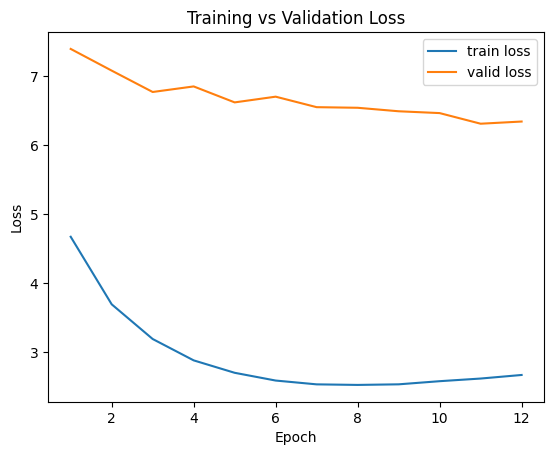

In [41]:
plt.figure()
plt.plot(range(1, N_EPOCHS + 1), train_losses, label="train loss")
plt.plot(range(1, N_EPOCHS + 1), valid_losses, label="valid loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.savefig(LOSS_CURVE_PATH)
plt.show()

In [23]:
def greedy_search(model,src,src_lens):
    model.eval()
    with torch.no_grad():
        encoder_outputs,hidden_state,cell_state=model.encoder(src,src_lens)
        mask = make_src_mask(src_lens.to(src.device), src.size(1))
        dec_hidden=torch.stack([hidden_state,hidden_state],dim=0)
        dec_cell=torch.stack([cell_state,cell_state],dim=0)
        dec_states=(dec_hidden,dec_cell)
        generated_tokens=[]
        input_token = torch.tensor([BOS]).unsqueeze(0).to(device)
        for i in range(25):
            output_scores,dec_states,alpha=model.decoder(input_token,dec_states,encoder_outputs,mask)
            best_score=output_scores.argmax(dim=1).item()
            if best_score==EOS:
                break
            generated_tokens.append(best_score)
            input_token=torch.tensor([[best_score]],device=device)
    return generated_tokens


In [33]:
def beam_search(model, src, src_lens, beam_size=5):
    model.eval()
    with torch.no_grad():
        encoder_outputs, hidden_state, cell_state = model.encoder(src, src_lens)
        mask = make_src_mask(src_lens.to(src.device), src.size(1))
        dec_hidden = torch.stack([hidden_state, hidden_state], dim=0)
        dec_cell = torch.stack([cell_state, cell_state], dim=0)
        dec_states = (dec_hidden, dec_cell)

        beam = [([BOS], 0.0, dec_states)]
        completed_beams = []

        for i in range(25):
            all_candidates = []

            for tokens, score, state in beam:
                if tokens[-1] == EOS:
                    completed_beams.append([tokens, score])
                    continue

                current_token = torch.tensor([[tokens[-1]]], device=device)

                output_scores, new_state, alpha = model.decoder(
                    current_token, state, encoder_outputs,mask
                )

                output_scores = torch.log_softmax(output_scores, dim=1)
                penalty = 1.5
                for t in set(tokens):
                    if t not in (BOS, EOS, PAD):
                        output_scores[0, t] -= penalty

                top_scores, top_token = output_scores.topk(
                    beam_size, dim=1
                )

                for j in range(beam_size):
                    new_token = top_token[0, j].item()
                    new_score = score + top_scores[0, j].item()

                    all_candidates.append(
                        (tokens + [new_token], new_score, new_state)
                    )

            all_candidates.sort(key=lambda x: x[1], reverse=True)
            beam = all_candidates[:beam_size]

        all_completed = completed_beams.copy()

        for tokens, score, _ in beam:
            all_completed.append((tokens, score))

        all_completed.sort(key=lambda x: x[1], reverse=True)

        best_tokens = all_completed[0][0]

        result = []

        for t in best_tokens:
            if t != BOS and t != EOS and t != PAD:
                result.append(t)

        return result


In [34]:
def generate_question(raw_text, sp_model, model):

    src_ids = sp_model.encode(raw_text)

    src_tensor = torch.tensor([src_ids], dtype=torch.long).to(device)
    src_lens = torch.tensor([len(src_ids)])

    greedy_tokens = greedy_search(model, src_tensor, src_lens)
    greedy_output = sp_model.decode(greedy_tokens)

    beam_tokens = beam_search(model, src_tensor, src_lens, beam_size=3)
    beam_output = sp_model.decode(beam_tokens)
    return greedy_output, beam_output



In [40]:
path = "/content/drive/MyDrive/Seq2Seq_Question_to_Answer/checkpointssss/best_checkpoint.pt"  # matches the folder Cell 16 actually saved to
print("Loading model from drive...")

data = torch.load(path, map_location=device)
if isinstance(data, dict) and "model_state_dict" in data:
    model.load_state_dict(data["model_state_dict"])
else:
    model.load_state_dict(data)

model.eval()
print("Model loaded!\n")

my_text = "لاہور کا قلعہ <ans> سولہویں صدی </ans> میں تعمیر کیا گیا"

g_out, b_out = generate_question(my_text, sp, model)

print("Source Text: ", my_text)
print("-" * 40)
print("Greedy Search Output: ", g_out)
print("Beam Search Output:   ", b_out)

Loading model from drive...
Model loaded!

Source Text:  لاہور کا قلعہ <ans> سولہویں صدی </ans> میں تعمیر کیا گیا
----------------------------------------
Greedy Search Output:  لاہ بہ تعمیر کس صدی میں تعمیر کیا گیا تھا؟
Beam Search Output:    لاہ  کا تعمیر کس صدی میں تعمیر کیا گیا تھا؟


In [28]:
src_ids = sp.encode(my_text)
src_tensor = torch.tensor([src_ids], dtype=torch.long).to(device)
src_lens = torch.tensor([len(src_ids)])

g_tokens = greedy_search(model, src_tensor, src_lens)
b_tokens = beam_search(model, src_tensor, src_lens, beam_size=3)

print("Greedy pieces:", [sp.id_to_piece(t) for t in g_tokens])
print("Beam pieces:  ", [sp.id_to_piece(t) for t in b_tokens])

Greedy pieces: ['▁کس', 'ع', 'ال', 'ہ', '▁کس', '▁پیدا', '▁ہوا', '▁تھا', '؟']
Beam pieces:   ['▁کس', 'ع', 'ال', 'ہ', '▁', 'ا', 'ق', '▁کب', '▁پیدا', '▁ہوا', '؟']


In [36]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}, valid_loss {checkpoint['valid_loss']:.4f}")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

import random
random.seed(42)  # same seed as before — lets you directly compare the same 8 examples across all three checkpoints
sample_idx = random.sample(range(len(valid_pairs)), 8)

for i in sample_idx:
    src, ref_tgt = valid_pairs[i]
    src_ids = sp.encode(src)
    src_tensor = torch.tensor([src_ids], dtype=torch.long).to(device)
    src_lens = torch.tensor([len(src_ids)])

    g_tokens = greedy_search(model, src_tensor, src_lens)
    b_tokens = beam_search(model, src_tensor, src_lens, beam_size=3)

    print("SRC: ", src)
    print("REF: ", ref_tgt)
    print("GREEDY:", sp.decode(g_tokens))
    print("BEAM:  ", sp.decode(b_tokens))
    print("-" * 50)

Loaded checkpoint from epoch 11, valid_loss 6.3137
SRC:  اوزون اوپری ماحول میں پیدا ہوتا ہے جب O-2 <ans> الٹرا وایلیٹ </ans> (یو وی) تابکاری کے ذریعہ O-2 کو تقسیم کرکے ایٹمی آکسیجن کے ساتھ مل جاتا ہے۔
REF:  اوزون کس روشنی کی تابکاری کو جذب کرتا ہے؟
GREEDY: اوزون کا مخفف کیا ہے؟
BEAM:   اوز کا مخفف کیا ہے؟
--------------------------------------------------
SRC:  جیسا کہ فورٹنو اور ہومر (2003) نے نشاندہی کی ہے ، کمپیوٹیشنل پیچیدگی میں منظم مطالعات کا آغاز جورس ہارٹ مینس اور رچرڈ سٹرنز (1965) کے کمپیوٹیشنل پیچیدگی کے بارے میں سیمینار کاغذ سے منسوب کیا جاتا ہے ، جس نے <ans> وقت اور جگہ </ans> کی پیچیدگی کی تعریفیں پیش کیں اور درجہ بندی کے نظریات کو ثابت کیا۔
REF:  "الگورتھم کی کمپیوٹیشنل پیچیدگی پر" کس پیچیدہ پیمائش کی وضاحت کی گئی تھی؟
GREEDY: ولیمپیلیشنل کی دو چیزیں کیا تھیں؟
BEAM:   ولیمپیلیشن کے کن کاموں کی طرف سے لاگو کیا گیا تھا؟
--------------------------------------------------
SRC:  یہ استدلال کیا گیا ہے کہ ، جبکہ سول نافرمانی اور <ans> سول بغاوت </ans> دونوں آئینی نقائص کی اپیل ک